<a href="https://colab.research.google.com/github/Faiq-danZ/worksafe-ai/blob/main/training/preprocessing_tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. MOUNT DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

path_raw       = '/content/drive/MyDrive/Data/Data/Raw/'
path_processed = '/content/drive/MyDrive/Data/Data/Processed/'

import os
os.makedirs(path_processed, exist_ok=True)
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## 2. IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries ready.")

Libraries ready.


## 3. LOAD DATASET

In [5]:
import pandas as pd
import os

# Daftar file sesuai dengan folder Raw
files = {
    'skills':          'Skills.xlsx',
    'work_activities': 'Work Activities.xlsx',
    'occupation':      'Occupation Data.xlsx',
    'job_zones':       'Job Zones.xlsx',       # File target
    'work_context':    'Work Context.xlsx',    # File tambahan jika diperlukan
    'task_statements': 'Task Statements.xlsx'  # File tambahan jika diperlukan
}

dataframes = {}

print("--- Memulai Proses Loading Data ---")
for key, fname in files.items():
    fpath = os.path.join(path_raw, fname)
    if os.path.exists(fpath):
        # Membaca file excel
        dataframes[key] = pd.read_excel(fpath)
        print(f"[OK] {fname} berhasil dimuat -> Ukuran: {dataframes[key].shape}")
    else:
        print(f"[WARNING] {fname} tidak ditemukan di folder Raw!")

print("\nStatus: Semua data yang tersedia telah siap di dictionary 'dataframes'.")

--- Memulai Proses Loading Data ---
[OK] Skills.xlsx berhasil dimuat -> Ukuran: (62580, 15)
[OK] Work Activities.xlsx berhasil dimuat -> Ukuran: (73308, 15)
[OK] Occupation Data.xlsx berhasil dimuat -> Ukuran: (1016, 3)
[OK] Job Zones.xlsx berhasil dimuat -> Ukuran: (923, 5)
[OK] Work Context.xlsx berhasil dimuat -> Ukuran: (297676, 16)
[OK] Task Statements.xlsx berhasil dimuat -> Ukuran: (18796, 8)

Status: Semua data yang tersedia telah siap di dictionary 'dataframes'.


## 4. EXPLORATORY CHECKING

In [6]:
for key, df in dataframes.items():
    print(f"\n{'='*45}")
    print(f"  {key.upper()}")
    print(f"  Shape  : {df.shape}")
    print(f"  Columns: {list(df.columns[:8])} ...")
    display(df.head(2))


  SKILLS
  Shape  : (62580, 15)
  Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N'] ...


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,IM,Importance,4.12,8,0.125,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,LV,Level,4.62,8,0.183,4.2664,4.9836,N,N,08/2023,Analyst



  WORK_ACTIVITIES
  Shape  : (73308, 15)
  Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Data Value', 'N'] ...


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,4.A.1.a.1,Getting Information,IM,Importance,4.56,29.0,0.1559,4.2369,4.8756,N,NaN,08/2023,Incumbent
1,11-1011.00,Chief Executives,4.A.1.a.1,Getting Information,LV,Level,4.89,30.0,0.1727,4.5393,5.2458,N,N,08/2023,Incumbent



  OCCUPATION
  Shape  : (1016, 3)
  Columns: ['O*NET-SOC Code', 'Title', 'Description'] ...


...

,O*NET-SOC Code,Title,Job Zone,Date,Domain Source
0,11-1011.00,Chief Executives,5,08/2023,Analyst
1,11-1011.03,Chief Sustainability Officers,5,08/2021,Analyst



  WORK_CONTEXT
  Shape  : (297676, 16)
  Columns: ['O*NET-SOC Code', 'Title', 'Element ID', 'Element Name', 'Scale ID', 'Scale Name', 'Category', 'Data Value'] ...


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Category,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CX,Context,NaN,3.07,37.0,0.2851,2.4923,3.6486,N,NaN,08/2023,Incumbent
1,11-1011.00,Chief Executives,4.C.1.a.2.c,Public Speaking,CXP,Context (Categories 1-5),1.0,0.13,37.0,0.1370,0.0160,1.0770,N,NaN,08/2023,Incumbent



  TASK_STATEMENTS
  Shape  : (18796, 8)
  Columns: ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source'] ...


,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent


## 5. MISSING VALUE CHECK

In [7]:
for key, df in dataframes.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    pct  = (miss / len(df) * 100).round(2)
    print(f"\n{key}:")
    if miss.empty:
        print("  Tidak ada missing value.")
    else:
        display(pd.DataFrame({'Missing': miss, '%': pct}))


skills:


,Missing,%
Not Relevant,31290,50.0



work_activities:


,Missing,%
N,1312,1.79
Standard Error,18532,25.28
Lower CI Bound,18550,25.30
Upper CI Bound,18550,25.30
Recommend Suppress,17302,23.60
Not Relevant,36654,50.00



occupation:
  Tidak ada missing value.

job_zones:
  Tidak ada missing value.

work_context:


,Missing,%
Category,50958,17.12
N,912,0.31
Standard Error,71892,24.15
Lower CI Bound,114452,38.45
Upper CI Bound,114452,38.45
Recommend Suppress,71037,23.86
Not Relevant,297676,100.00



task_statements:


,Missing,%
Task Type,845,4.50
Incumbents Responding,1190,6.33


## 6. DUPLICATE CHECK

In [8]:
for key, df in dataframes.items():
    n = df.duplicated().sum()
    print(f"{key}: {n} duplikat")

skills: 0 duplikat
work_activities: 0 duplikat
occupation: 0 duplikat
job_zones: 0 duplikat
work_context: 0 duplikat
task_statements: 0 duplikat


## 7. PIVOT HELPER & PROCESS TIAP DATASET

In [10]:
def pivot_onet(df, prefix):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df = df[['O*NET-SOC Code', 'Element Name', 'Data Value']]
    pivot = df.pivot_table(
        index='O*NET-SOC Code',
        columns='Element Name',
        values='Data Value',
        aggfunc='mean'
    ).reset_index()
    pivot.columns = [
        'onet_code' if c == 'O*NET-SOC Code'
        else prefix + c.lower().replace(' ', '_').replace('/', '_')
        for c in pivot.columns
    ]
    return pivot

df_skills     = pivot_onet(dataframes['skills'], 'skl_')       if 'skills'          in dataframes else None
df_knowledge  = pivot_onet(dataframes['knowledge'], 'knw_')    if 'knowledge'       in dataframes else None
df_activities = pivot_onet(dataframes['work_activities'], 'act_') if 'work_activities' in dataframes else None

for name, df in [('Skills', df_skills), ('Knowledge', df_knowledge), ('Work Activities', df_activities)]:
    if df is not None:
        print(f"{name} pivot: {df.shape}")

Skills pivot: (894, 36)
Work Activities pivot: (894, 42)


## 8. MERGE SEMUA DATASET

In [11]:
df_occ = dataframes['occupation'].copy()
df_occ.columns = df_occ.columns.str.strip()
df_occ.rename(columns={'O*NET-SOC Code': 'onet_code', 'Title': 'occupation_title'}, inplace=True)

df_merged = df_occ[['onet_code', 'occupation_title']].copy()

for df_part in [df_skills, df_knowledge, df_activities]:
    if df_part is not None:
        df_merged = df_merged.merge(df_part, on='onet_code', how='left')

print(f"Merged shape: {df_merged.shape}")
display(df_merged.head(3))

Merged shape: (1016, 78)


,onet_code,occupation_title,skl_active_learning,skl_active_listening,skl_complex_problem_solving,skl_coordination,skl_critical_thinking,skl_equipment_maintenance,skl_equipment_selection,skl_installation,...,act_repairing_and_maintaining_electronic_equipment,act_repairing_and_maintaining_mechanical_equipment,act_resolving_conflicts_and_negotiating_with_others,act_scheduling_work_and_activities,act_selling_or_influencing_others,act_staffing_organizational_units,act_thinking_creatively,act_training_and_teaching_others,act_updating_and_using_relevant_knowledge,act_working_with_computers
0,11-1011.00,Chief Executives,4.125,4.375,4.63,4.565,4.565,0.5,0.685,0.5,...,0.970,0.740,5.105,4.120,4.36,4.290,4.385,4.385,4.700,3.600
1,11-1011.03,Chief Sustainability Officers,3.815,4.000,4.06,3.815,4.120,0.5,0.685,0.5,...,1.205,1.095,4.070,4.280,4.59,3.760,4.590,3.925,4.945,3.685
2,11-1021.00,General and Operations Managers,3.685,4.060,3.75,3.940,3.880,0.5,0.500,0.5,...,1.880,1.870,4.385,3.865,3.67,4.015,3.825,3.600,3.985,4.305


## 9. FEATURE ENGINEERING: BUAT RISK LABEL

In [12]:
# Risk dibuat dari profil skill pekerjaan mengikuti pendekatan
# Frey & Osborne (2013): pekerjaan rutin + manual = risiko tinggi

from sklearn.preprocessing import MinMaxScaler

num_cols = df_merged.select_dtypes(include=np.number).columns.tolist()

# Cari proxy untuk skill rutin/manual
routine_proxy = [c for c in num_cols if any(
    x in c for x in ['equipment', 'operation', 'control', 'manual', 'finger', 'trunk']
)]

# Cari proxy untuk skill kognitif/kompleks
cognitive_proxy = [c for c in num_cols if any(
    x in c for x in ['critical_thinking', 'active_learning', 'complex', 'judgment',
                      'systems', 'science', 'math', 'programming']
)]

print(f"Routine proxy  : {len(routine_proxy)} fitur")
print(f"Cognitive proxy: {len(cognitive_proxy)} fitur")

# Fallback jika tidak ketemu
if len(routine_proxy) == 0:
    routine_proxy = num_cols[:8]
if len(cognitive_proxy) == 0:
    cognitive_proxy = num_cols[-8:]

df_merged['routine_score']   = df_merged[routine_proxy].mean(axis=1)
df_merged['cognitive_score'] = df_merged[cognitive_proxy].mean(axis=1)

mms = MinMaxScaler()
df_merged[['routine_score', 'cognitive_score']] = mms.fit_transform(
    df_merged[['routine_score', 'cognitive_score']]
)

df_merged['risk_score_raw'] = (
    0.65 * df_merged['routine_score'] +
    0.35 * (1 - df_merged['cognitive_score'])
)

def to_risk_label(score):
    if score >= 0.60:   return 2  # High
    elif score >= 0.35: return 1  # Medium
    else:               return 0  # Low

df_merged['risk_label'] = df_merged['risk_score_raw'].apply(to_risk_label)

print("\nDistribusi label:")
print(df_merged['risk_label'].value_counts().rename({0:'Low', 1:'Medium', 2:'High'}))

Routine proxy  : 13 fitur
Cognitive proxy: 9 fitur

Distribusi label:
risk_label
Medium    393
Low       349
High      274
Name: count, dtype: int64


## 10. FEATURE SELECTION (TOP 50 KORELASI)

In [13]:
candidates = [c for c in num_cols if c not in ['routine_score', 'cognitive_score', 'risk_score_raw']]

corr = df_merged[candidates + ['risk_score_raw']].corr()['risk_score_raw'].abs()
top_features = corr.drop('risk_score_raw').nlargest(50).index.tolist()

print(f"Fitur terpilih: {len(top_features)}")
print(top_features[:5], "...")

Fitur terpilih: 50
['act_repairing_and_maintaining_mechanical_equipment', 'act_controlling_machines_and_processes', 'skl_operation_and_control', 'skl_equipment_maintenance', 'skl_troubleshooting'] ...


## 11. IMPUTATION & SCALING

In [15]:
df_final = df_merged[top_features + ['risk_label', 'onet_code']].copy()
df_final.dropna(thresh=int(len(df_final.columns) * 0.6), inplace=True)

imputer = SimpleImputer(strategy='median')
df_final[top_features] = imputer.fit_transform(df_final[top_features])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[top_features])
df_scaled = pd.DataFrame(X_scaled, columns=top_features, index=df_final.index)

print(f"Shape setelah imputation & scaling: {df_scaled.shape}")

Shape setelah imputation & scaling: (894, 50)


## 12. TRAIN-TEST SPLIT

In [16]:
y = df_final['risk_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    df_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"Label train: {pd.Series(y_train).value_counts().to_dict()}")

Train: (715, 50)
Test : (179, 50)
Label train: {1: 314, 2: 219, 0: 182}


## 13. VISUALISASI DISTRIBUSI LABEL

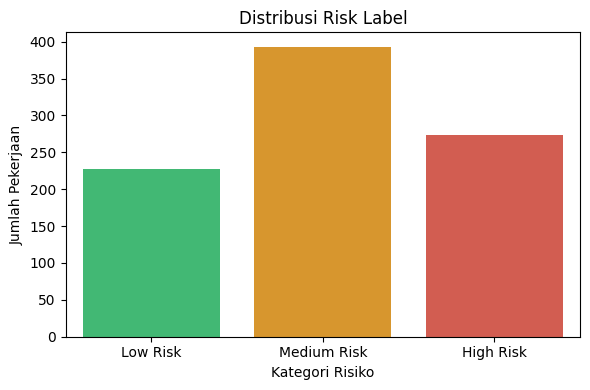

In [18]:
label_map = {0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}

plt.figure(figsize=(6, 4))
sns.countplot(
    x=pd.Series(y).map(label_map),
    order=['Low Risk', 'Medium Risk', 'High Risk'],
    palette=['#2ecc71', '#f39c12', '#e74c3c']
)
plt.title('Distribusi Risk Label')
plt.xlabel('Kategori Risiko')
plt.ylabel('Jumlah Pekerjaan')
plt.tight_layout()
plt.savefig(path_processed + 'label_distribution.png', dpi=100)
plt.show()

## 14. SIMPAN DATASET & PREPROCESSING OBJECTS

In [19]:
df_train_out = X_train.copy(); df_train_out['risk_label'] = y_train
df_test_out  = X_test.copy();  df_test_out['risk_label']  = y_test

df_full = df_scaled.copy()
df_full['risk_label'] = y
df_full['onet_code']  = df_final['onet_code'].values

df_train_out.to_csv(path_processed + 'train_data.csv', index=False)
df_test_out.to_csv(path_processed  + 'test_data.csv',  index=False)
df_full.to_csv(path_processed      + 'data_siap_training.csv', index=False)

with open(path_processed + 'scaler.pkl', 'wb') as f:  pickle.dump(scaler, f)
with open(path_processed + 'imputer.pkl', 'wb') as f: pickle.dump(imputer, f)
with open(path_processed + 'feature_cols.pkl', 'wb') as f: pickle.dump(top_features, f)

print("Semua file berhasil disimpan:")
print(f"  data_siap_training.csv : {df_full.shape}")
print(f"  train_data.csv         : {df_train_out.shape}")
print(f"  test_data.csv          : {df_test_out.shape}")
print("  scaler.pkl, imputer.pkl, feature_cols.pkl")

Semua file berhasil disimpan:
  data_siap_training.csv : (894, 52)
  train_data.csv         : (715, 51)
  test_data.csv          : (179, 51)
  scaler.pkl, imputer.pkl, feature_cols.pkl
